In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [3]:
from sklearn.metrics import confusion_matrix

cm =confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    classification_report
)

In [8]:
acs = accuracy_score(y_test, y_pred)

prs = precision_score(y_test, y_pred, average='weighted')

f1s = f1_score(y_test, y_pred, average='weighted')

res = recall_score(y_test, y_pred, average='weighted')

clr = classification_report(y_test, y_pred)

print(acs)
print(prs)
print(f1s)
print(res)
print(clr)

0.9666666666666667
0.9696969696969696
0.9665831244778613
0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



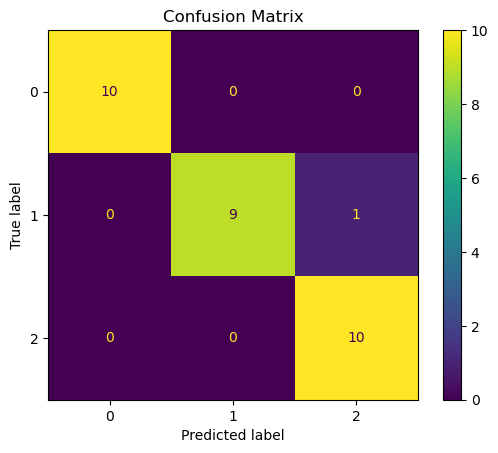

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix")
plt.show()

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier()
}

In [12]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = (accuracy)

for name, score in results.items():
    print(f"{name}: {score:.4f}")

LogisticRegression: 0.9667
KNN: 1.0000
Random Forest: 0.9000
Gradient Boosting: 0.9667
Decision Tree: 0.9667


In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    print(
        f'{name} '
        f'Mean={scores.mean():.4f} '
        f'Std={scores.std():.4f}'
    )

LogisticRegression Mean=0.9583 Std=0.0264
KNN Mean=0.9750 Std=0.0204
Random Forest Mean=0.9500 Std=0.0312
Gradient Boosting Mean=0.9500 Std=0.0312
Decision Tree Mean=0.9500 Std=0.0167
